# Spherical anomaly model in two-layered earth

Forward model with an embedded spherical anomaly (eps_r = 20) in a two-layered earth background.

The background reference is the Evert two-layer solution (no anomaly). The difference between the anomaly and background responses is the target signature.

In [1]:
import sys, os, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

# ── locate solver root relative to this notebook ────────────────────────────────
MASTER_PATH = Path(r"..\elfe3D_GPR").resolve()


# inputs
from elfe3d_gpr.inputs.survey import GPRSurvey
from elfe3d_gpr.inputs.anomalies import SphereAnomaly

# runner
from elfe3d_gpr.runner import ProjectPaths, run_tetgen, run_solver

# outputs
from elfe3d_gpr.outputs.fieldreader import AnalyticalLoader, ElfeLoader, load_elfe_batch
from elfe3d_gpr.outputs.postprocess import field_error, field_simple_error, error_stats
from elfe3d_gpr.outputs.visualize   import (ReceiverLinePlot, ReceiverLineErrorPlot,
                          ReceiverLineCombined, ErrorHistogramPlot, 
                          ReceiverLineSimpleErrorPlot, SimpleErrorHistogramPlot)


---
## Paths and runtime configuration

In [2]:
# ── set once per machine ───────────────────────────────────────────────────
paths = ProjectPaths(
    master_dir = MASTER_PATH,
    exec_rel   = '',
    use_wsl    = True,   # False if running the solver directly inside WSL
)

print('Solver root:', MASTER_PATH)
print('Executable:', paths.exec_path())


Solver root: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR
Executable: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\elfe3d_gpr


---
## 1 — Build and write inputs

Same background as the two-layered example, plus a `SphereAnomaly`

In [3]:
f    = 100e6
wave = 3e8 / f

BASE_DIR = MASTER_PATH

survey = GPRSurvey.build(
    experiment_name="anomaly_sphere",
    base_dir=BASE_DIR,

    # Domain
    x_e=[-wave/10, 1 + wave/10],
    y_e=[-wave/10, wave/10],
    z_e=[-1.0 - wave/10/3, wave/10],

    # Materials — air + 2 earth layers
    air_eps_r=1.0,
    air_sigma=1e-16,
    layer_thicknesses=[1.0, wave/10/3],
    layer_eps_r=[4.0, 9.0],
    layer_sigma=[1e-4, 1e-3],
    layer_mu_r=[1.0, 1.0],
    layer_sigma_m=[0.0, 0.0],

    anomalies=[
        SphereAnomaly(
            center=(0.0, 0.0, -0.7),
            radius=wave/16,
            properties=(20, 1e-4, 1.0, 0.0),   # (eps_r, sigma, mu_r, sigma_m)
        )
    ],

    # Source
    f_list=[f],
    antenna_position=[0.0, 0.0, 0.025],
    source_type=6,
    current_direction=1,
    num_segments=1,
    s_f=250,
    bh_f=1.0,
    box_present=False,
    box_x=[-1 + 0.75, 1 + 0.375],
    m=5,

    # Receivers
    num_receivers_inline=48, # @TODO: Fix
    num_receivers_endfire=0,
    num_receivers_oblique=0,

    # Solver
    solver_type=2,
    max_ref_steps=0,
    max_unknowns=5_000_000,
    accuracy_tol=3e-5,
    output_fields_vtk=1,

    # PML
    num_pml_layers=1,
    pml_layer_thickness=wave/10,
    pml_type="lin",
    pml_decay_type=1,

    least_samples_per_wavelength=10,
)

survey.generate()

print('poly :', survey.io.poly_file)


odepths: [np.float64(0.075), np.float64(0.0375), np.float64(0.025)]
Source antenna length: 0.0006 m
Receiver antenna depth: -0.00015 m
[0.0, -1.0]
Input generation complete.
poly : F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\GPR_model_anomaly_sphere.poly


---
## 2 — Mesh with TetGen

In [4]:
run_tetgen(paths, survey.io.poly_file)

Opening GPR_model_anomaly_sphere.poly.
Delaunizing vertices...
Delaunay seconds:  0.017493
Creating surface mesh ...
Surface mesh seconds:  0.006586
Constrained Delaunay...
Constrained Delaunay seconds:  0.011886
Removing exterior tetrahedra ...
Spreading region attributes.
Exterior tets removal seconds:  0.000804
Refining mesh...
Refinement seconds:  0.920828
Optimizing mesh...
Optimization seconds:  0.048031

Writing GPR_model_anomaly_sphere.1.node.
Writing GPR_model_anomaly_sphere.1.ele.
Writing GPR_model_anomaly_sphere.1.face.
Writing GPR_model_anomaly_sphere.1.edge.
Writing GPR_model_anomaly_sphere.1.vtk.
Writing GPR_model_anomaly_sphere.1.neigh.

Output seconds:  0.913593
Total running seconds:  1.91946

Statistics:

  Input points: 2804
  Input facets: 5247
  Input segments: 8049
  Input holes: 0
  Input regions: 46

  Mesh points: 52737
  Mesh tetrahedra: 318881
  Mesh faces: 641263
  Mesh edges: 375118
  Mesh faces on facets: 38371
  Mesh edges on segments: 9522
  Steiner poin

---
## 3 — Run solver

In [5]:
run_solver(paths,survey)

***************************************
GPR forward modelling with elfe3D_GPR
***************************************
Your forward problem is solved with
 MUMPS
*************************************
Reading refinement information
Your mesh will be refined
 for             0 refinement steps
 or until     5000000 unknowns
 with error estim. method           3
 with refinement strategy           1
Your output files will be generated in: /out
Field components in the domain will be in *.vtk file in: /in
*************************************
Reading model definitions
Your input meshfile is called
 in/GPR_model_anomaly_sphere.                      
Your mesh has
       52737 Nodes
      318881 Elements
      375118 Edges (dof)
*************************************
Assembling connectivity arrays
Calculating interpolation coefficients
Obtaining model properties
*************************************
Source parameters:
 CSTYPE           6
 source-start coordinates:
  -2.9999999999999997E-004   0

---
## 4 — Load results

In [6]:
result_txt = survey.io.output_dir / 'electric_fields_receiver_line.txt'
print('reading:', result_txt)

ef = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D layered sphere anomaly',
    num_endfire = 48,
).endfire()

print(f'r : {ef.r.min():.3f} – {ef.r.max():.3f} m   ({len(ef.r)} receivers)')


reading: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_anomaly_sphere\electric_fields_receiver_line.txt
r : 0.100 – 1.000 m   (48 receivers)


---
## 5 — Background reference

In [7]:
# Background reference = two-layer model without the anomaly
# Same CSV as the two-layered example — the anomaly response is the
# difference between this and the anomaly run.
ANALYTICAL_DIR = r'F:\Projects\EMGeoInversion\elfe3D_GPR\data\data_semi_analytical'

bg = AnalyticalLoader(
    os.path.join(ANALYTICAL_DIR, 'Exx_single_freq_4_9_100MHz_NR.csv'),
    label='Background (Evert)',
).endfire()


---
## 6 — Anomaly vs background comparison

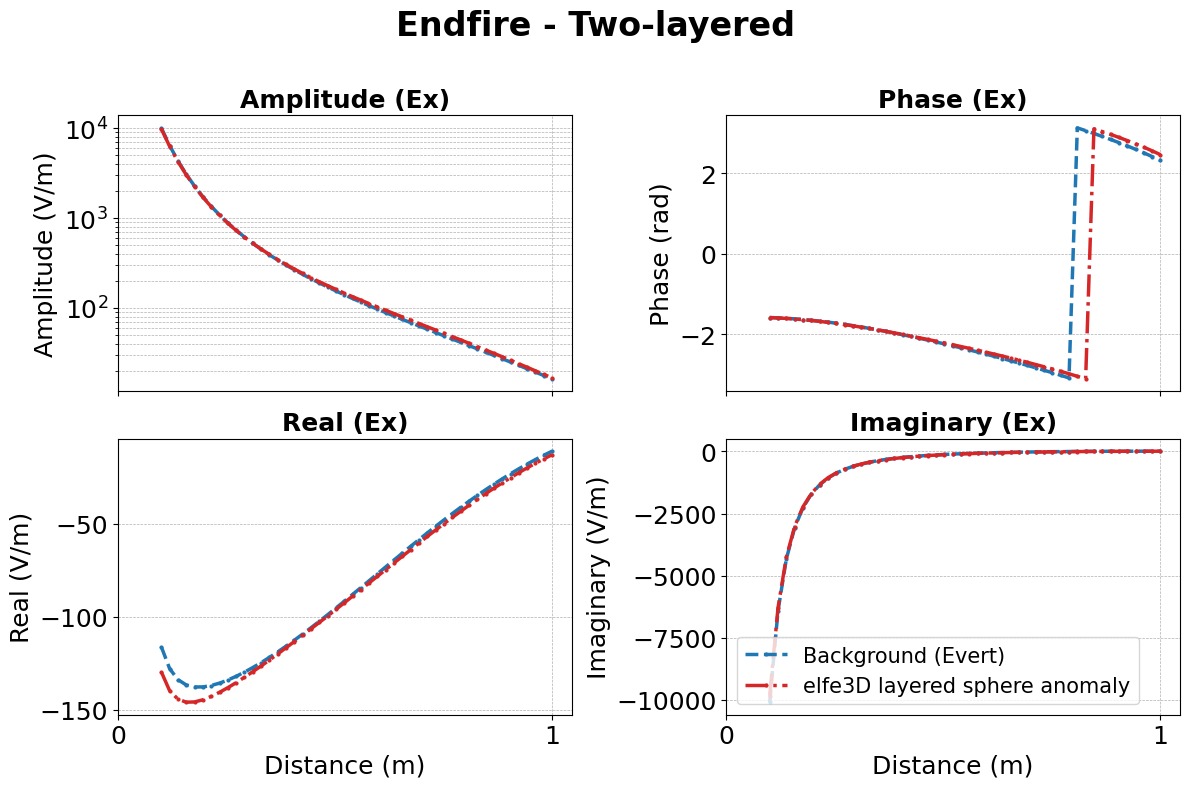

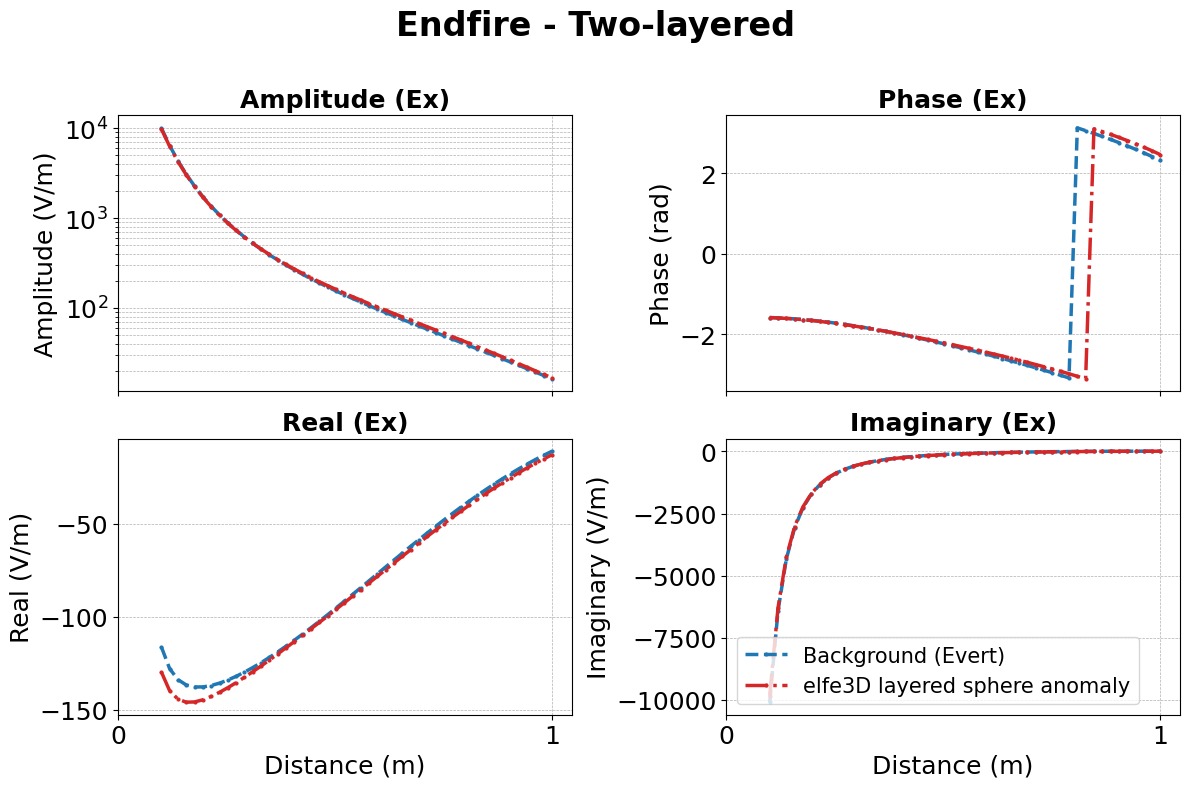

In [8]:
ReceiverLinePlot([bg, ef]).plot(suptitle="Endfire - Two-layered")

## Anomaly response  (difference from background)

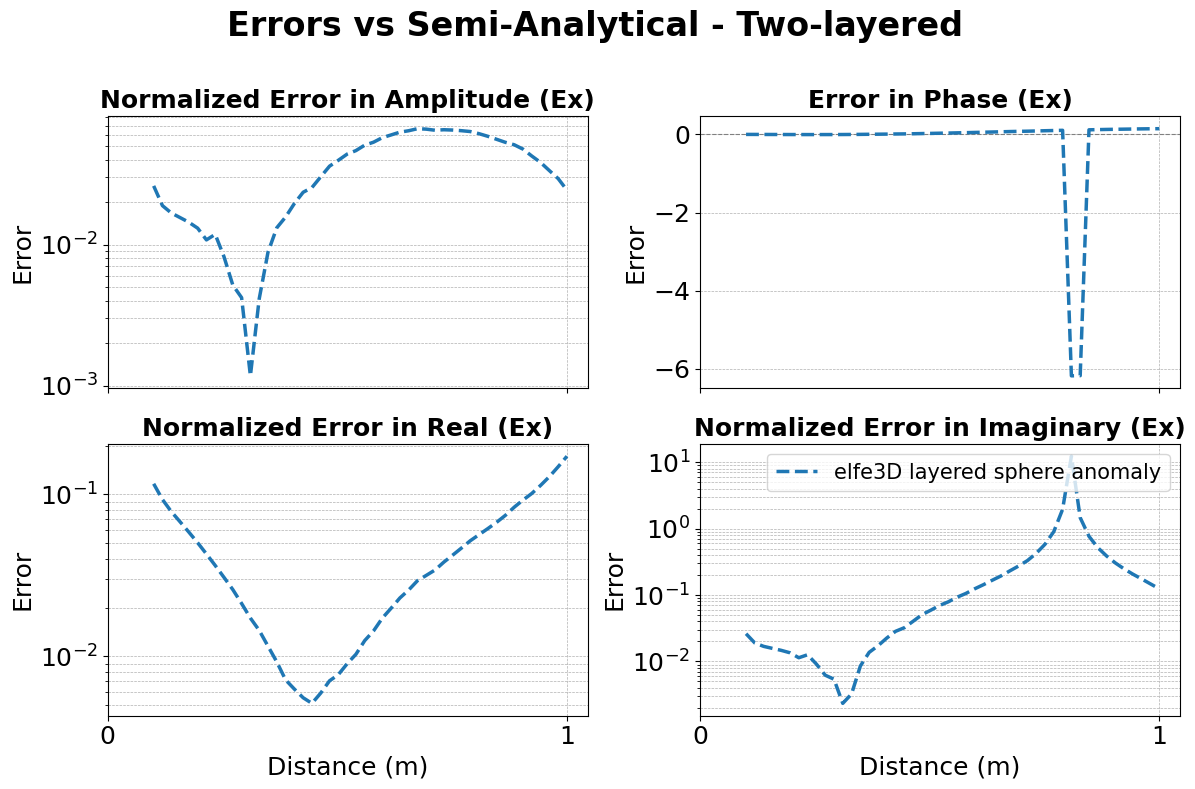

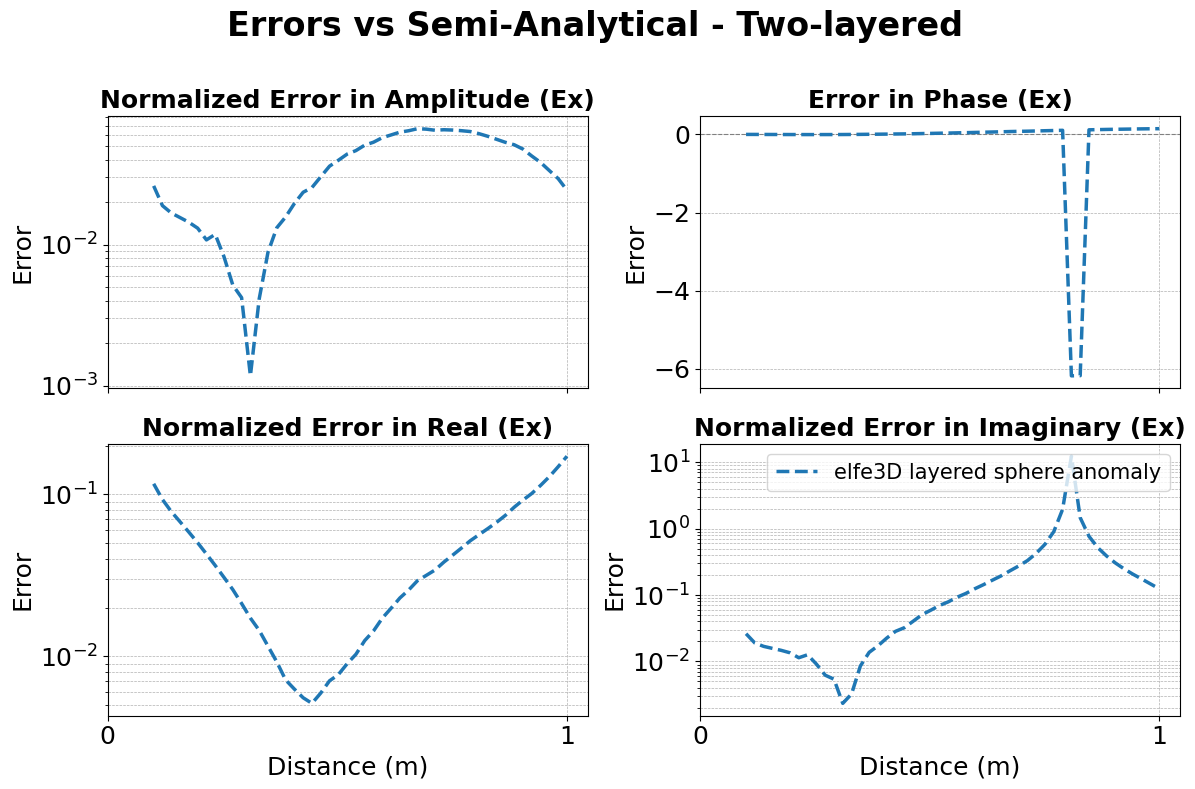

In [9]:
ReceiverLineErrorPlot([ef], reference=bg).plot(suptitle="Errors vs Semi-Analytical - Two-layered")

## Combined (fields + anomaly response)

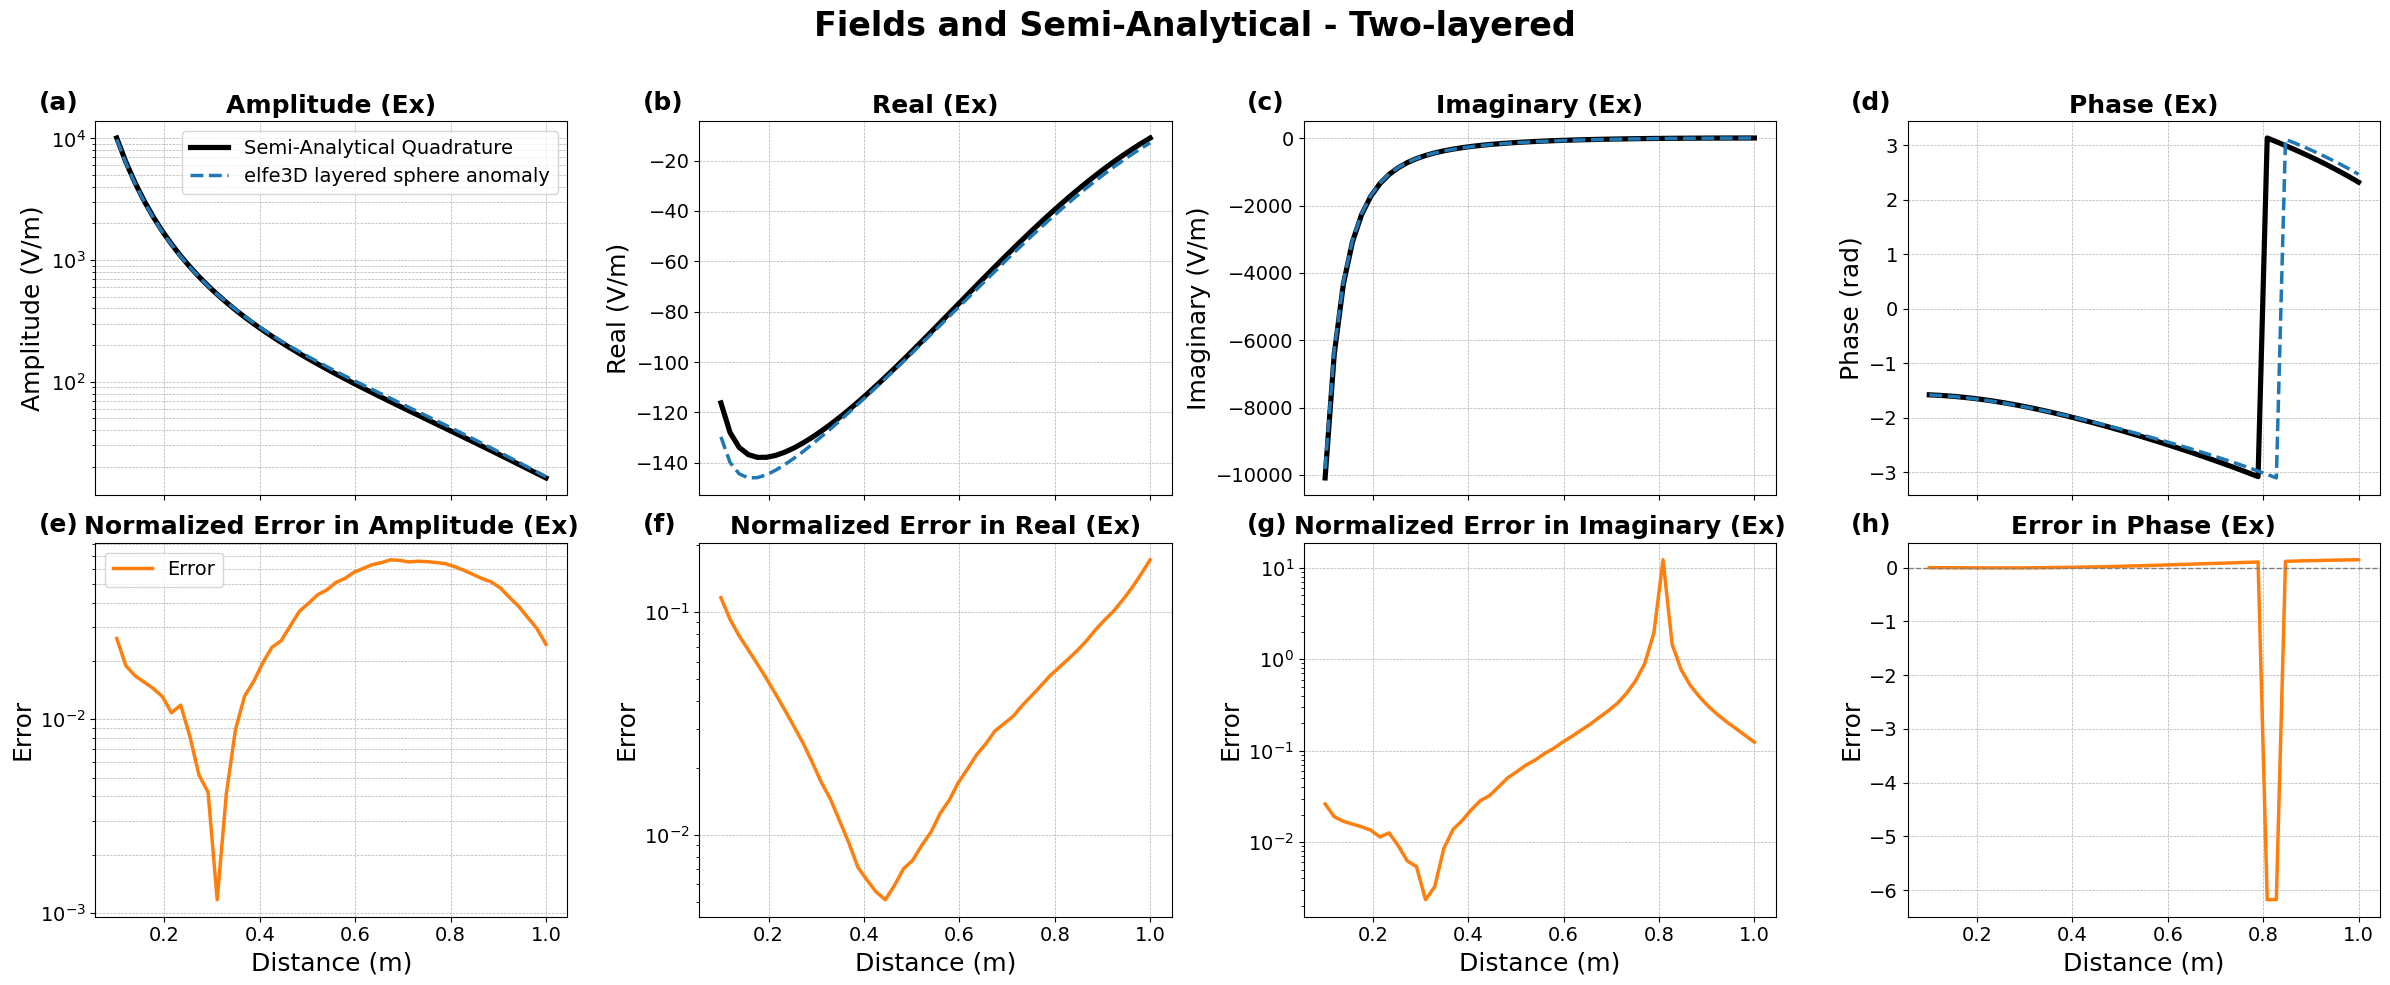

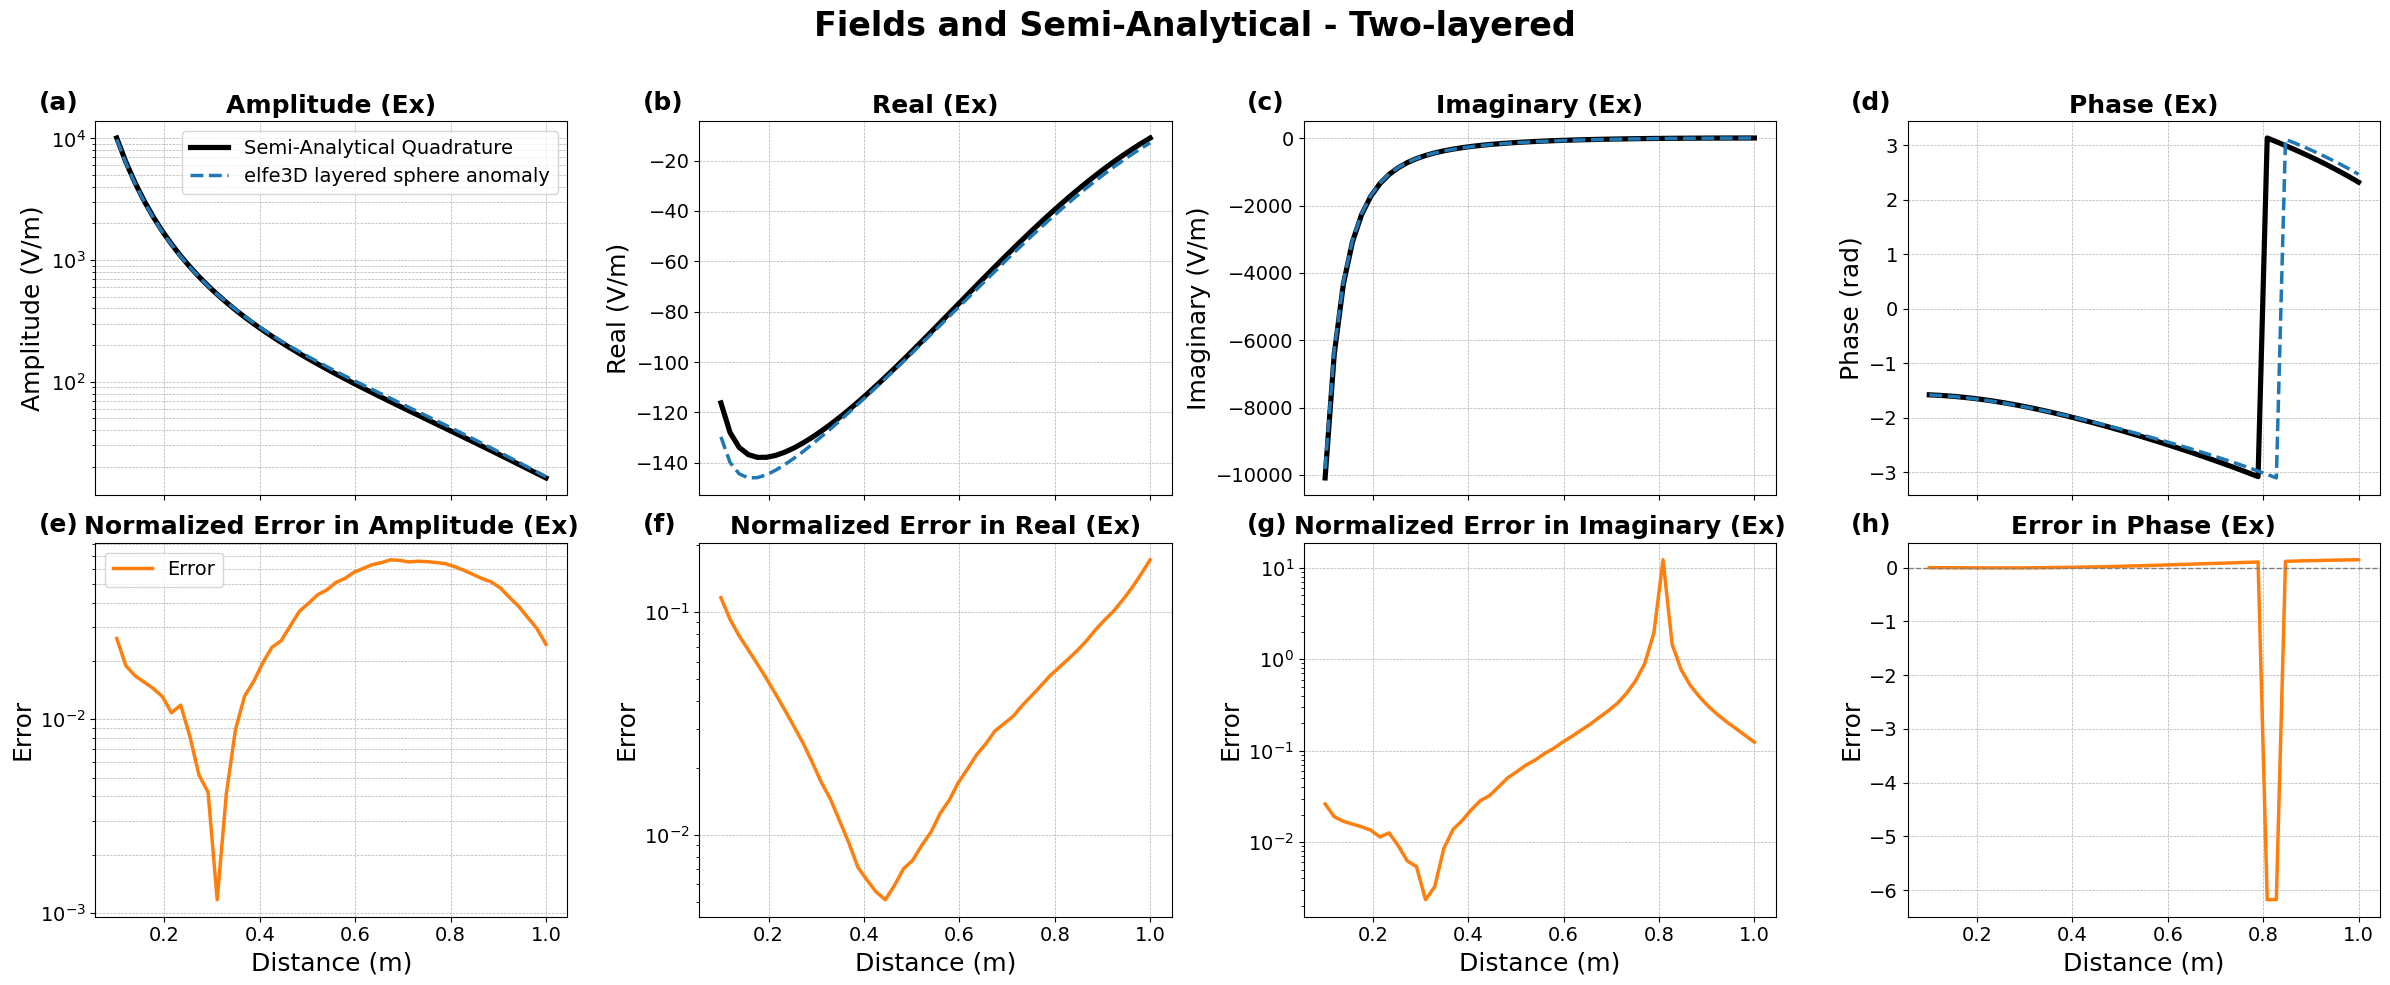

In [10]:
ReceiverLineCombined(ef, bg).plot(suptitle="Fields and Semi-Analytical - Two-layered")

## Response distribution histogram

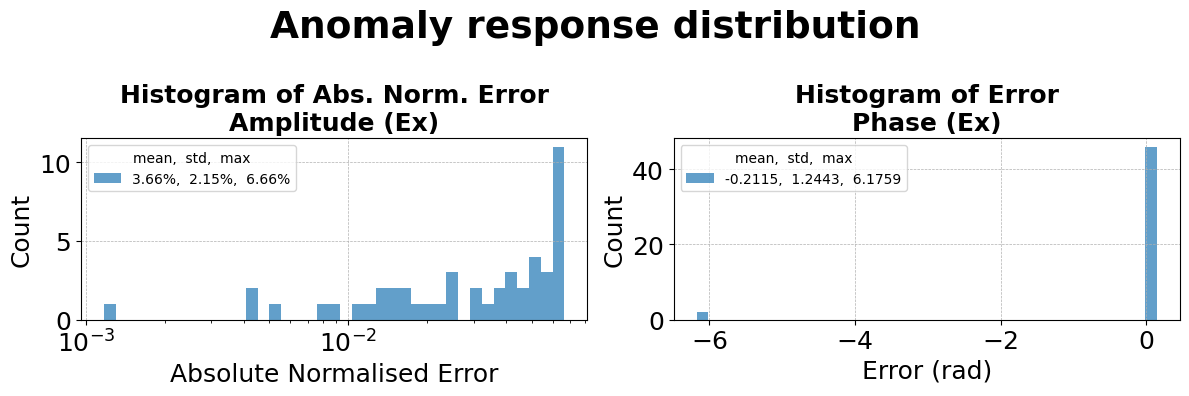

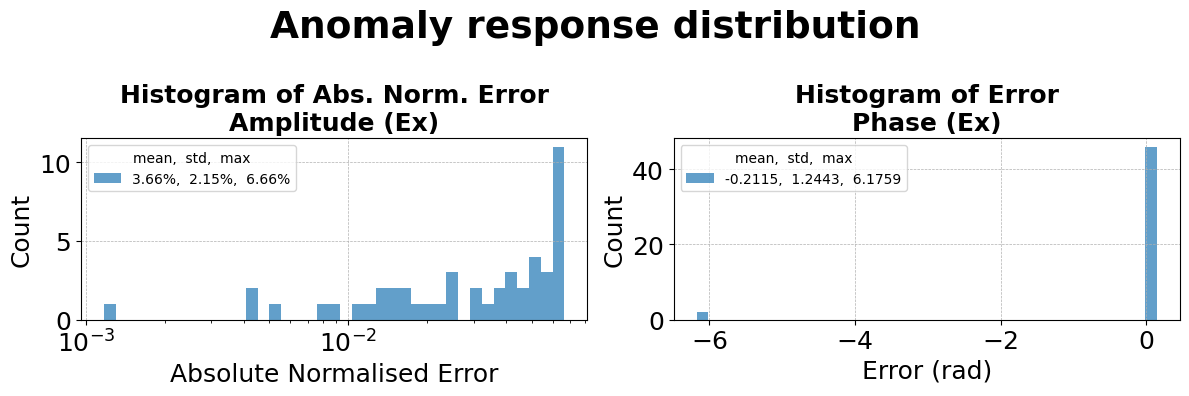

In [11]:
ErrorHistogramPlot([ef], reference=bg).plot(suptitle='Anomaly response distribution',)

## Printed anomaly response summary

In [12]:
qty_names = ['Amplitude', 'Phase', 'Real', 'Imaginary']
print('Anomaly response (relative to two-layer background)\n')
for qi, name in enumerate(qty_names):
    err = field_error(bg, ef, qi)
    m, s, mx = error_stats(err)
    scale, unit = (100, '%') if qi != 1 else (1, 'rad')
    print(f'  {name:12s}:  mean={m*scale:.3f}{unit}  '
          f'std={s*scale:.3f}{unit}  max={mx*scale:.3f}{unit}')


Anomaly response (relative to two-layer background)

  Amplitude   :  mean=3.657%  std=2.155%  max=6.660%
  Phase       :  mean=-0.211rad  std=1.244rad  max=6.176rad
  Real        :  mean=4.626%  std=4.062%  max=17.182%
  Imaginary   :  mean=47.263%  std=175.938%  max=1226.363%


## Finding the Sphere's Field Signature

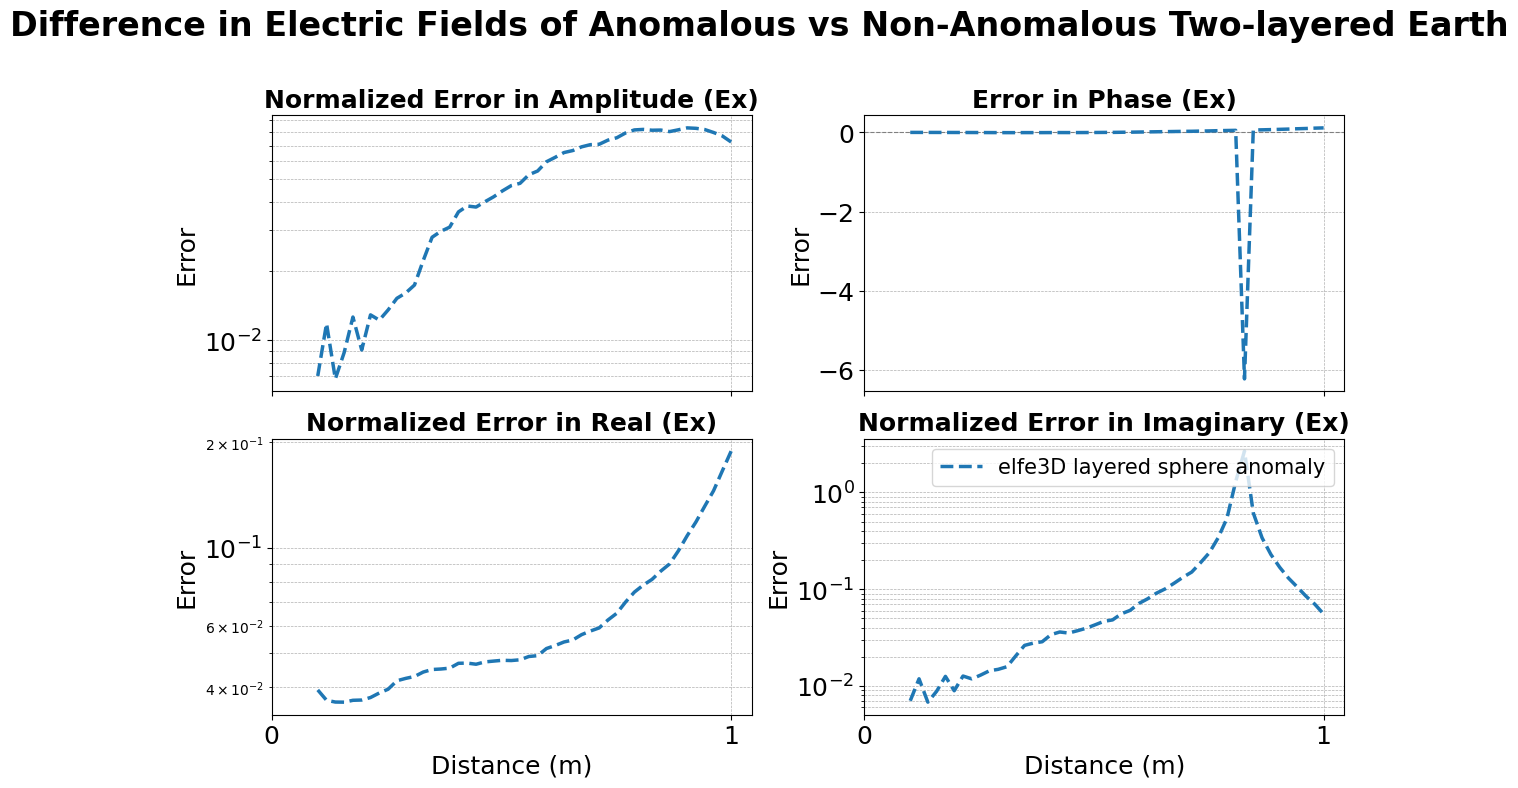

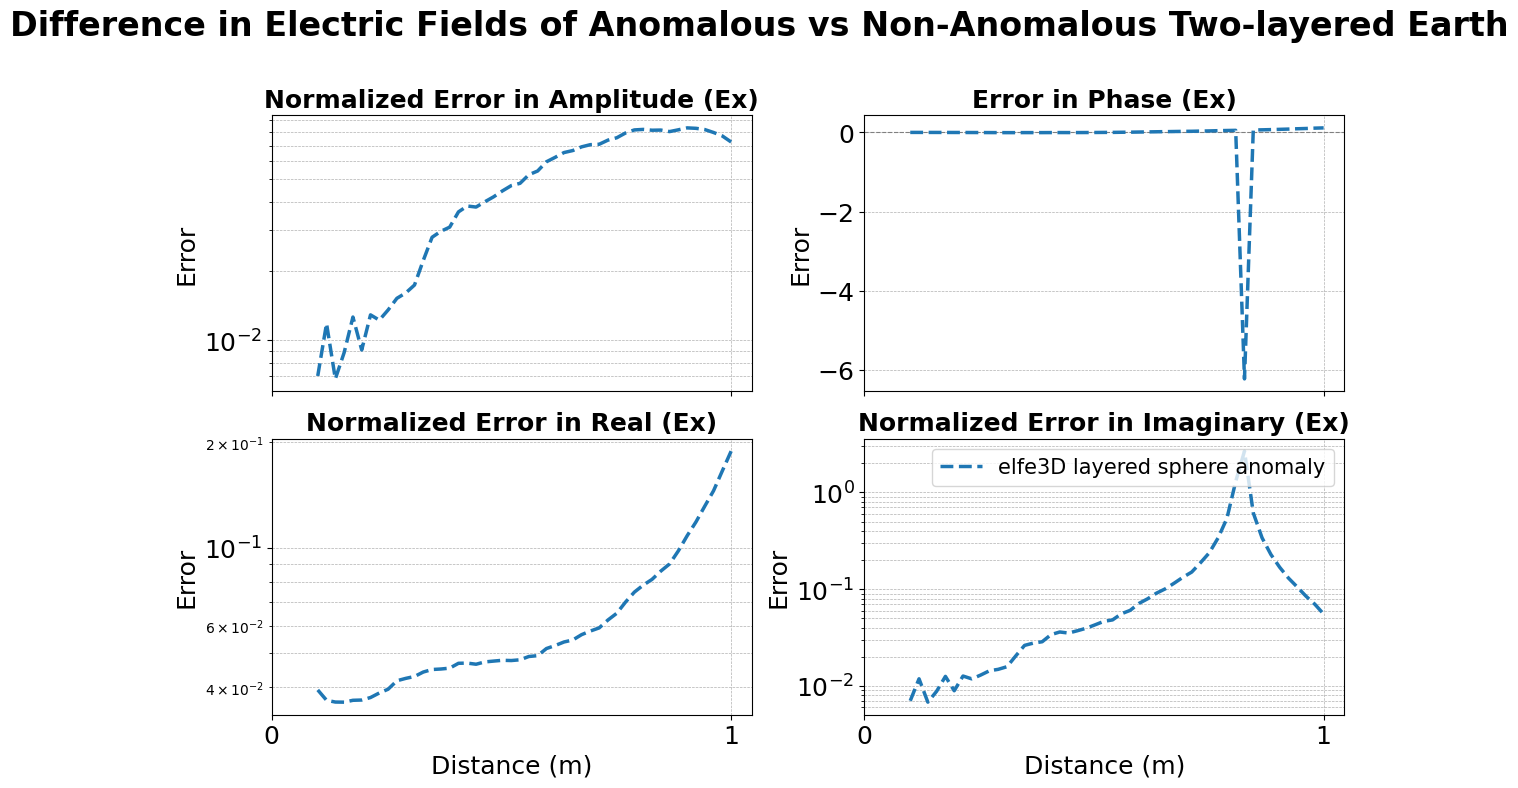

In [13]:
two_layered_txt = os.path.join(BASE_DIR, 'out_two_layered_earth', 'electric_fields_receiver_line.txt')

tl = ElfeLoader(
    filepath    = str(two_layered_txt),
    label       = 'two-layered earth',
    num_endfire = 48,
).endfire()

ReceiverLineErrorPlot([ef], reference=tl).plot(suptitle="Difference in Electric Fields of Anomalous vs Non-Anomalous Two-layered Earth")

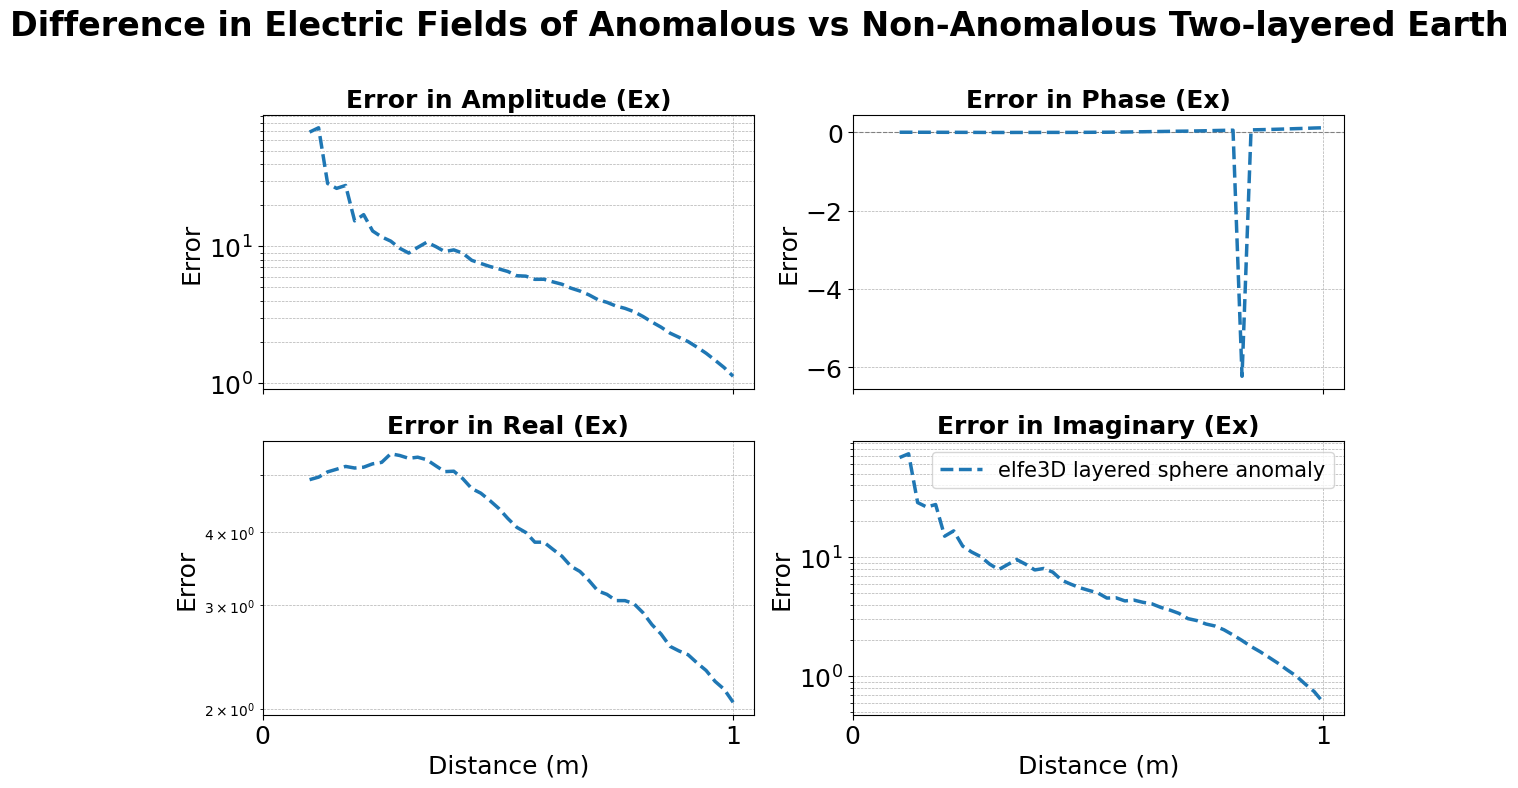

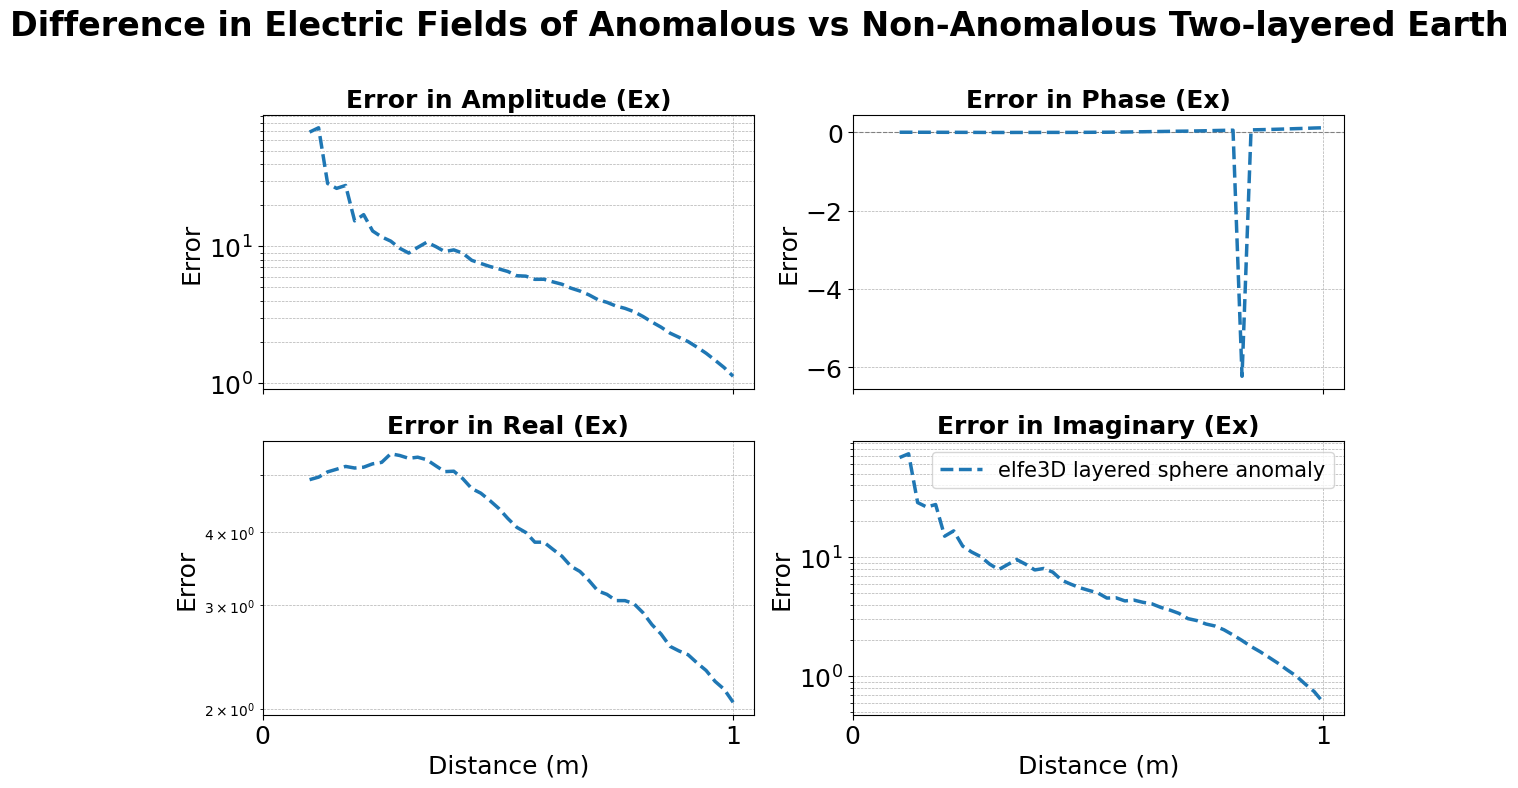

In [14]:
ReceiverLineSimpleErrorPlot([ef], reference=tl).plot(suptitle="Difference in Electric Fields of Anomalous vs Non-Anomalous Two-layered Earth")

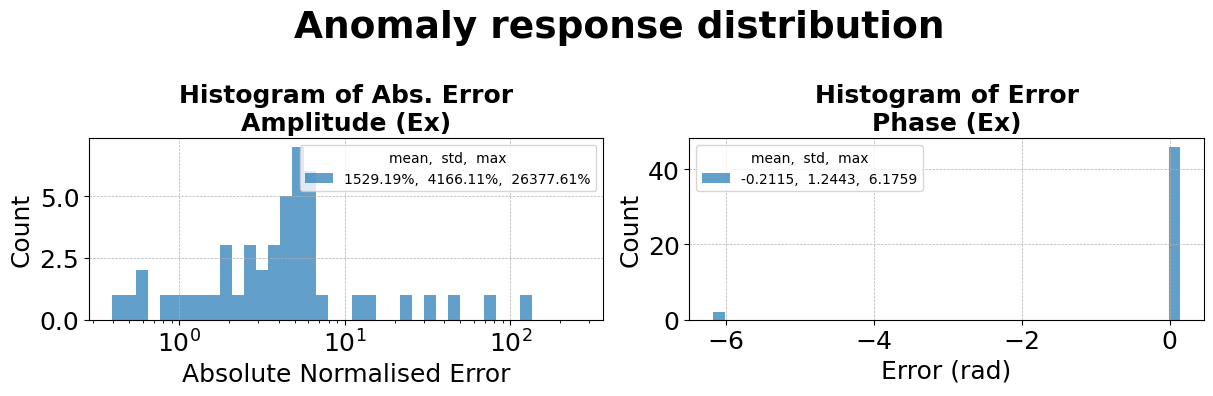

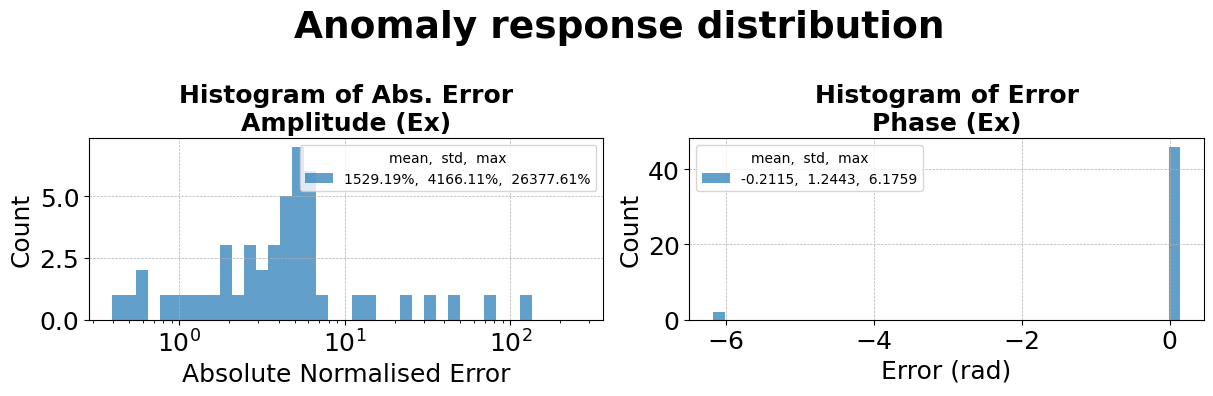

In [15]:
SimpleErrorHistogramPlot([ef], reference=bg).plot(suptitle='Anomaly response distribution',)